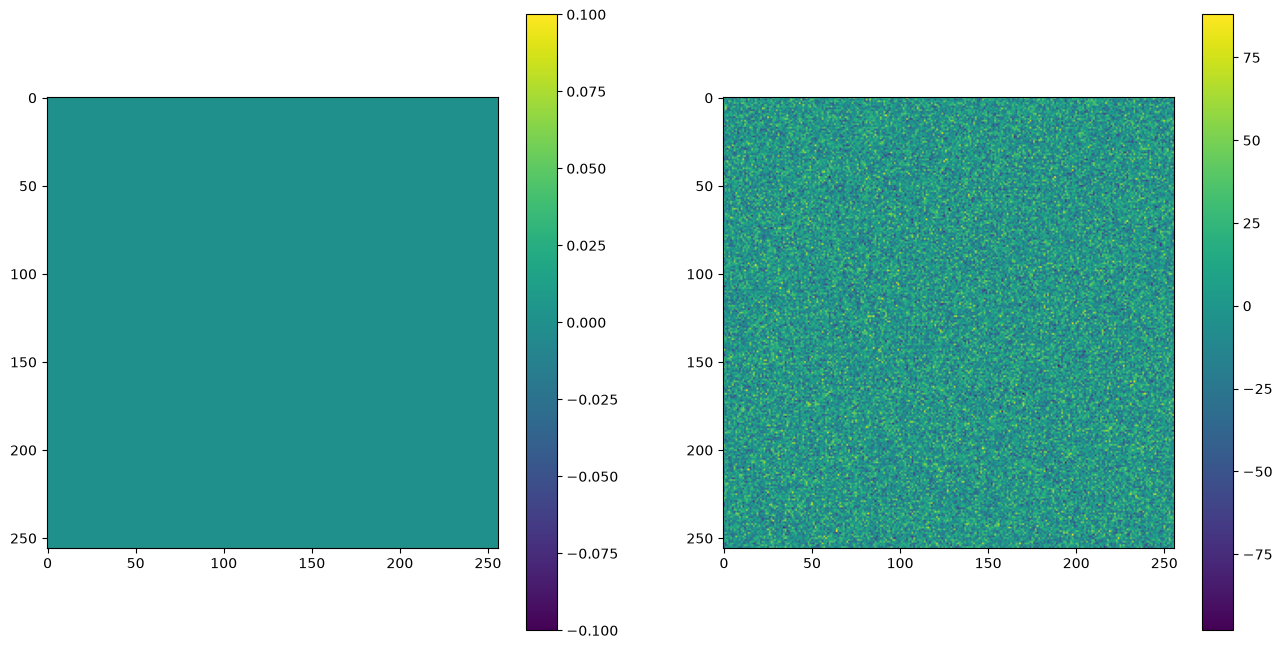

array([27.99081246])

In [1]:
# Press Release mock image ROSALIA
# Alejandro Borlaff - NASA Ames Research Center
# a.s.borlaff@nasa.gov - August 5, 2026

# Plan: 
# Make a mock exposure object. 
# Run stray-light model. 

import rosalia as rs 
from astropy.time import Time
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
os.chdir("/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK")
# Let's define the minimum parameters to generate a dummy Roman / WFI image
# To get some challenging environment, let's target the Pleiades.
ra = 88.23938768241827  # Right ascension, in degrees. 
dec = -48.53277317761877  # Declination, in degrees.
PA = 98.22514198825647  # Position angle, in degrees.
date = Time('2026-12-01T00:00:00.0', format='isot', scale='utc')


def add_shot_noise(image, poisson_limit=1e7):
    poisson_region = np.where((image < poisson_limit))
    gaussian_region = np.where((image >= poisson_limit))

    image[poisson_region] =  np.random.poisson(image[poisson_region])
    image[gaussian_region] =  np.random.normal(image[gaussian_region], np.sqrt(image[gaussian_region]))

    return(image)

test_array = np.zeros((256, 256)) + 500

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16,8))
im=ax[0].imshow(test_array-500)
fig.colorbar(im, ax=ax[0])
im=ax[1].imshow(add_shot_noise(image=test_array)-500)
fig.colorbar(im, ax=ax[1])
plt.show()
rs.detectors.fe2mu(fe=3E-3, instrument="WFI", filter_name="F129", telescope="Roman")


In [2]:
rs.detectors.fe2mu(fe=0.15, instrument="WFI", filter_name="F129", telescope="Roman")


array([23.74338745])

In [ ]:
# Reorganize Pablo's galaxies
reference_lvl2 = fits.open("/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stars.fits") 

if False:
    for filter_pablo in ["F062", "F129", "F158"]:
        galaxies = fits.open("roman_full_fov_Cosmo_FIRE_BIGFIRE_RENDER_"+filter_pablo+"_detectors.fits")

        for i in range(len(reference_lvl2)-1):
            mu = -2.5*np.log10(np.flip(galaxies[i+1].data, axis=0)) + 23.9 +5*np.log10(0.108) + 1.5 # Pablo Cor. 
            espx = rs.detectors.mu2fe(mu, instrument="WFI", filter_name=filter_pablo, telescope="Roman")
            reference_lvl2[i+1].data = espx.value # rs.utils.mu2fe

        reference_lvl2.writeto("/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_"+filter_pablo+"_galaxies.fits", overwrite=True)
        rs.utils.run_swarp("/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_"+filter_pablo+"_galaxies.fits", 
                        "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_"+filter_pablo+"_galaxies_drz.fits",)

KeyboardInterrupt: 

In [5]:
# Final test  
exptime = 193 #  294
nexposures = 20

if True:
    for bandpass in ["F129", "F184", "F087"]:
        if bandpass == "F087": filter_pablo = "F062"
        if bandpass == "F129": filter_pablo = "F129"
        if bandpass == "F184": filter_pablo = "F158"


        stray_name  = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_" + bandpass + "_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stray_drz.fits"
        zodi_name   = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_" + bandpass + "_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_zody_drz.fits"
        stars_name  = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_" + bandpass + "_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stars_drz.fits"
        FIRE_name   = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_" + filter_pablo + "_galaxies_drz.fits"

        stray=fits.open(stray_name, memmap=True)
        zodi=fits.open(zodi_name, memmap=True)
        stars=fits.open(stars_name, memmap=True)
        FIRE=fits.open(FIRE_name, memmap=True)

        all = np.nansum(np.array([stray[0].data, zodi[0].data, 0.5*stars[0].data, FIRE[0].data]), axis=0)*exptime
        all[all==0] = np.nan
        all[all<=0] = np.nan
        all = np.float32(all)
        rs.utils.save_fits(all/exptime, "all_" + bandpass + ".fits", stray[0].header)

        if True: 
            os.system("mkdir EXPOSURES")
            for i in tqdm(range(nexposures)):
                all_noise =  add_shot_noise(image=all) # np.random.poisson(all*exptime)
                all_noise = np.float32(all_noise)
                outname = "all_" + bandpass + ".fits"
                all_noise[np.isnan(all)] = np.nan
                print(outname)
                expname = "EXPOSURES/all_" + bandpass + "_noise_frame"+str(i).zfill(3) + ".fits"
                rs.utils.save_fits(all_noise/exptime, expname, stray[0].header)
                print(expname)


    # Make a scaled version 
    os.system("astwarp all_F087_noise.fits -h0 --scale=0.2,0.2")
    os.system("astwarp all_F129_noise.fits -h0 --scale=0.2,0.2")
    os.system("astwarp all_F184_noise.fits -h0 --scale=0.2,0.2")

    for bandpass in ["F184", "F129", "F087"]:
        os.system("astwarp all_"+bandpass+"_noise.fits -h0 --scale=0.2,0.2")
        image_scaled = fits.open("all_"+bandpass+"_noise_scaled.fits")
        image_scaled[1].data =  image_scaled[1].data*(0.2**2)
        image_scaled[1].data[image_scaled[1].data == 0] = np.nan
        image_scaled.verify("silentfix")
        image_scaled.writeto("all_"+bandpass+"_noise_scaled.fits", overwrite=True)


"""
nozody = np.nansum(np.array([stray[0].data, stars[0].data, FIRE[0].data, cosmic[0].data]), axis=0) 
nozody[nozody==0] = np.nan
rs.utils.save_fits(nozody*exptime, "nozody_" + bandpass + ".fits", stray[0].header)

nostars = np.nansum(np.array([stray[0].data, FIRE[0].data, cosmic[0].data]), axis=0) 
nostars[nostars==0] = np.nan
rs.utils.save_fits(nostars*exptime, "nostars_" + bandpass + ".fits", stray[0].header)

nostray = np.nansum(np.array([FIRE[0].data, 0.1*cosmic[0].data]), axis=0) 
nostray[nostray==0] = np.nan
rs.utils.save_fits(nostray*exptime, "nostray_" + bandpass + ".fits", stray[0].header)
"""

mkdir: EXPOSURES: File exists
  0%|          | 0/20 [00:00<?, ?it/s]

all_F129.fits


  5%|▌         | 1/20 [00:23<07:20, 23.20s/it]

EXPOSURES/all_F129_noise_frame000.fits
all_F129.fits


 10%|█         | 2/20 [00:44<06:40, 22.26s/it]

...

EXPOSURES/all_F087_noise_frame018.fits
all_F087.fits


100%|██████████| 20/20 [07:38<00:00, 22.92s/it]

EXPOSURES/all_F087_noise_frame019.fits



astwarp: all_F087_noise.fits: No such file or directory
astwarp: all_F129_noise.fits: No such file or directory
astwarp: all_F184_noise.fits: No such file or directory
astwarp: all_F184_noise.fits: No such file or directory
astwarp: all_F129_noise.fits: No such file or directory
astwarp: all_F087_noise.fits: No such file or directory


'\nnozody = np.nansum(np.array([stray[0].data, stars[0].data, FIRE[0].data, cosmic[0].data]), axis=0) \nnozody[nozody==0] = np.nan\nrs.utils.save_fits(nozody*exptime, "nozody_" + bandpass + ".fits", stray[0].header)\n\nnostars = np.nansum(np.array([stray[0].data, FIRE[0].data, cosmic[0].data]), axis=0) \nnostars[nostars==0] = np.nan\nrs.utils.save_fits(nostars*exptime, "nostars_" + bandpass + ".fits", stray[0].header)\n\nnostray = np.nansum(np.array([FIRE[0].data, 0.1*cosmic[0].data]), axis=0) \nnostray[nostray==0] = np.nan\nrs.utils.save_fits(nostray*exptime, "nostray_" + bandpass + ".fits", stray[0].header)\n'

In [7]:
 zodi[0].data

In [7]:
import os
import glob 
if True: # Lets do the BAD skycorrection 
    for bandpass in ["F184", "F129", "F087"]:
        indiv_exposures = glob.glob("EXPOSURES/all_" + bandpass + "_noise_frame[0-9][0-9][0-9].fits")
        for indiv_exposure in indiv_exposures:
            print(indiv_exposure)
            os.system("astnoisechisel -K -h0 " + indiv_exposure)
            # os.system("swarp -BACK_SIZE 2048 -MEM_MAX 8150 " + indiv_exposure + " -IMAGEOUT_NAME " + indiv_exposure.replace(".fits", "_badsky.fits"))

EXPOSURES/all_F184_noise_frame010.fits
NoiseChisel 0.24 started on Mon Aug 17 17:23:56 2026
  - Using 10 CPU threads.
  - Input: EXPOSURES/all_F184_noise_frame010.fits (hdu: 0)
  - Kernel: FWHM=2 pixel Gaussian.
  - Convolved with given kernel.                       19.014873 seconds
  - Starting to find initial detections.
  ---- 0.30 & 0.99 quantile thresholds applied.        45.113244 seconds
  ---- Eroded 2 times (4-connected).                   1.902229 seconds
  ---- Opened (depth: 1, 8-connected).                 2.484394 seconds
  - 682784 initial detections found.                   53.035018 seconds
  - Starting to find/remove false detections.
  ---- Initial (crude) Sky and its STD found.          41.916094 seconds
  ---- Pseudo-detection thresh (0.000 sigma) applied.  0.435706 seconds
  ---- Pseudo-det S/N: 5.597 (0.99 quant of 444620).   9.432297 seconds
  ---- 657763 false initial detections removed.        4.809377 seconds
  ---- Growth to 0.900 quantile complete.        

In [9]:
for bandpass in ["F184", "F129", "F087"]:
    #os.system("astarithmetic -g1 -K /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_" + bandpass + "_noise_frame*_detected.fits 20 median")
    os.system("astwarp -K -h1 /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_" + bandpass + "_noise_frame000_detected_arith.fits --scale=0.2,0.2")
    #os.system("astarithmetic -g0 -K /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_" + bandpass + "_noise_frame*badsky.fits 20 median")
    #os.system("astwarp -K -h0 /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_" + bandpass + "_noise_frame000_badsky.fits --scale=0.2,0.2")
    

Warp 0.24 started on Tue Aug 18 09:22:09 2026
 Using 10 CPU threads.
 Input: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_F184_noise_frame000_detected_arith.fits (hdu: 1)
 matrix:
	 0.2000    0.0000    0.0000
	 0.0000    0.2000    0.0000
	 0.0000    0.0000    1.0000
 Output: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_F184_noise_frame000_detected_arith_scaled.fits
Warp finished in:  9.454433 seconds
Warp 0.24 started on Tue Aug 18 09:22:19 2026
 Using 10 CPU threads.
 Input: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_F129_noise_frame000_detected_arith.fits (hdu: 1)
 matrix:
	 0.2000    0.0000    0.0000
	 0.0000    0.2000    0.0000
	 0.0000    0.0000    1.0000
 Output: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_F129_noise_frame000_detected_arith_scaled.fits
Warp finished in:  9.040703 seconds
Warp 0.24 started on Tue Aug 18 09:22:28 2026
 Using 10 CPU threads.
 Input: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_F087_

In [ ]:
# Let's do the GOOD skycorrection 
import glob
if True: # Lets do the BAD skycorrection 
    for bandpass in ["F184", "F129", "F087"]:
        indiv_exposures = glob.glob("EXPOSURES/all_" + bandpass + "_noise_frame[0-9][0-9][0-9].fits")


        stray_name  = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_" + bandpass + "_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stray_drz.fits"
        zodi_name   = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_" + bandpass + "_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_zody_drz.fits"
        stars_name  = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_" + bandpass + "_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stars_drz.fits"

        stray=fits.open(stray_name, memmap=True)
        zodi=fits.open(zodi_name, memmap=True)
        stars=fits.open(stars_name, memmap=True)

        for indiv_exposure in tqdm(indiv_exposures):
            print(indiv_exposure)
            exp_fits=fits.open(indiv_exposure, memmap=True)
            exp_fits[0].data = exp_fits[0].data - (stray[0].data + zodi[0].data + 0.1*stars[0].data)
            exp_fits.verify("silentfix")
            exp_fits.writeto(indiv_exposure.replace(".fits", "_goodsky.fits"), overwrite=True)          



In [ ]:
for bandpass in ["F184", "F129", "F087"]:
    os.system("astarithmetic -g0 -K /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_" + bandpass + "_noise_frame*goodsky.fits 20 mean")
    os.system("astwarp -K -h0 /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/EXPOSURES/all_" + bandpass + "_noise_frame000_goodsky.fits --scale=0.2,0.2")
    

In [ ]:
# Reorganize level 3 to level 2 for Pablo
import astropy.wcs as astropy_wcs

reference_lvl2 = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stars.fits"
for bandpass in ["F184", "F129", "F087"]:

    level3_name = "EXPOSURES/T294/all_"+ bandpass +"_noise_frame000_goodsky_arith.fits"
    level3 = fits.open(level3_name, memmap=True)
    level3_wcs = astropy_wcs.WCS(header=level3[1].header, fobj=level3, naxis=2)

    reference_lvl2_fits = fits.open(reference_lvl2, memmap=True)
    for i in tqdm(range(18)):
        blot_sca, blot_header = rs.utils.reproject_roman_wfi_fits(data_list=[level3[1].data],
                                                                  wcs_list=[level3_wcs], 
                                                                  reference_name=reference_lvl2, 
                                                                  reference_ext=i+1)
        reference_lvl2_fits[i+1].data = blot_sca[0]
        reference_lvl2_fits[i+1].header = blot_header

    reference_lvl2_fits.verify("silentfix")
    reference_lvl2_fits.writeto(level3_name.replace("_arith.fits", "_lvl2.fits"), overwrite=True)


In [ ]:
# Reorganize Zodi level 3 to level 2 for Pablo
import astropy.wcs as astropy_wcs

reference_lvl2 = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stars.fits"
for bandpass in ["F062", "F129", "F158"]: # ["F184", "F129", "F087"]:

    level3_name = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/zody_" + bandpass + "_drz.fits" # "EXPOSURES/T294/all_"+ bandpass +"_noise_frame000_goodsky_arith.fits"
    level3 = fits.open(level3_name, memmap=True)
    level3_wcs = astropy_wcs.WCS(header=level3[0].header, fobj=level3, naxis=2)

    reference_lvl2_fits = fits.open(reference_lvl2, memmap=True)
    for i in tqdm(range(18)):
        blot_sca, blot_header = rs.utils.reproject_roman_wfi_fits(data_list=[level3[0].data],
                                                                  wcs_list=[level3_wcs], 
                                                                  reference_name=reference_lvl2, 
                                                                  reference_ext=i+1)
        reference_lvl2_fits[i+1].data = blot_sca[0]
        reference_lvl2_fits[i+1].header = blot_header

    reference_lvl2_fits.verify("silentfix")
    reference_lvl2_fits.writeto(level3_name.replace(".fits", "_lvl2.fits"), overwrite=True)

In [ ]:
level3

In [ ]:
reference_lvl2_fits.writeto(level3_name.replace("_arith.fits", "_lvl2.fits"), overwrite=True)

In [ ]:
os.system("astarithmetic all_F184_noise.fits all_F184_noise.fits 0.0 eq nan where -g0")
os.system("astnoisechisel --tilesize=100,100 all_F184_noise_arith.fits")


In [ ]:
4*193

In [ ]:
a = np.zeros((256,256))+30
a = add_shot_noise(a)
plt.imshow(all)
plt.colorbar()

In [ ]:
import os
os.system("astarithmetic all_F129_noise.fits all_F129_noise.fits 0.0 eq nan where -g0")
os.system("astnoisechisel -h1 all_F129_noise_arith.fits")

In [ ]:
from astropy.io import fits 
import numpy as np

a = fits.open("all_F129_noise.fits")
b = fits.open("PR_mock_F129_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_zody_drz.fits")
d = fits.open("all_F129_noise_arith_detected.fits")

a[0].data = a[0].data - b[0].data * 4 * 193
a[0].data[d["DETECTED"].data != 0] = np.nan

a.verify("silentfix")
a.writeto("all_F129_noise_sky.fits")


In [ ]:
d = fits.open("all_F129_noise_arith_detected.fits")

a[0].data = a[0].data - b[0].data * 4 * 193
a[0].data[d["DETECTED"].data != 0] = np.nan

a.verify("silentfix")
a.writeto("all_F129_noise_sky.fits")

In [ ]:
rs.detectors.fe2mu(fe=2, instrument="WFI", filter_name="F213", telescope="Roman")
